In [5]:
pip install biopython

Note: you may need to restart the kernel to use updated packages.


Ejercicio 3.1 Dot-Plot y filtros

a) cree una matriz de ceros (de dimensión de acuerdo a las longitudes de seq1 y se2) y luego recorra todas las casillas poniendo 1 donde hay un match y 0 donde hay mismatch (consejo pruebe con una matriz más pequeña y luego vaya por la  completa).

b) Arme un modulo para graficar el dot-plot.

c) Programe un filtro que -opere sobre el dot-plot obtenido (el window-size “w” debería ser una variable a modificar), y reanalice los resultados. Hay varias alternativas para programar el filtro, como ser relacionadas con si las ventanas se encuentran superpuestas o son adyacentes, y si el dotplot es reemplazado por el dotplot de las ventanas y/o las mismas son solo utilizadas como filtro. Ademas se puede setear el umbral (vea el grafico para mayor claridad). Programe y compare las diferentes opciones.

In [7]:
from Bio import Entrez, SeqIO
Entrez.email = "solernadina@gmail.com"
ids = ["NP_000509.1", "NP_000518.1"]

records = []

for seq_id in ids:
    try:
        handle = Entrez.efetch(db="protein", id=seq_id, rettype="fasta", retmode="text")
        record = SeqIO.read(handle, "fasta")
        records.append(record)
        handle.close()
    except Exception as e:
        print(f"Error con {seq_id}: {e}")

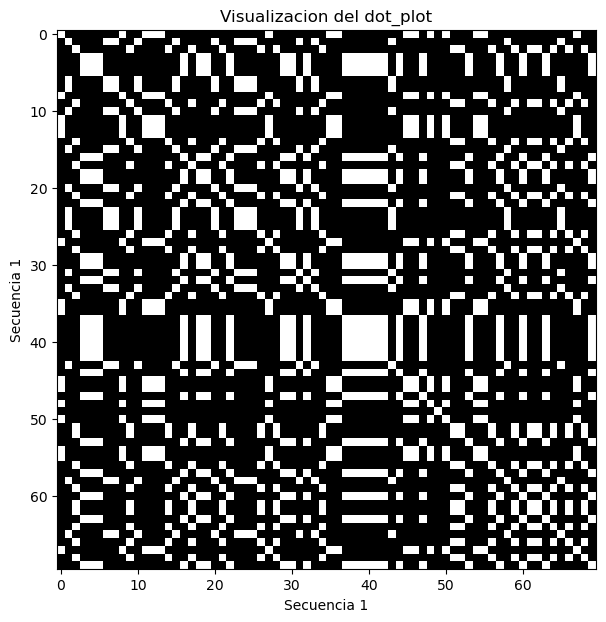

In [8]:
import numpy as np 
from Bio.Seq import Seq
import matplotlib.pyplot as plt

# Me quedo solo con la secuencia que es lo que me interesa 
#seq1 = records[0].seq
#seq2 = records[1].seq

seq1 = "TCGAAACCTGCTTTGCAGAACGACCCGTGAACACGTTAAAAAACATTATRTGGATTGACGAGGAGCGTGA"
seq2 = "GCTCTTAATCATCCATTGTCGGGTCATGGGATYGACCATGGTTGATCTTATGCTCTCGTACAAACACAAA"
def generar_dotplot(seq1, seq2):
    # convertimos las secuencias fasta a string
    seq1, seq2 = str(seq1), str(seq2)

    # Armamos matriz de ceros
    dot_plot = np.zeros((len(seq1), len(seq2)))
    # Recorremos ambas secuencias y completamos la matriz
    # Consideramos seq1 para filas y seq2 para columnas
    for i, aa1 in enumerate(seq1):
        for j, aa2 in enumerate(seq2):
            if aa1 == aa2:
                dot_plot[i,j] = 1
            else:
                dot_plot[i,j] = 0
    return dot_plot
    
dotplot = generar_dotplot(seq1,seq1)
plt.figure(figsize=(7,7))
plt.imshow(dotplot, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
plt.xlabel("Secuencia 1")
plt.ylabel("Secuencia 1")
plt.title("Visualizacion del dot_plot")
plt.show()

 

Para programar el filtro tenemos 2 opciones. Usar convolucion sobre la imagen, o programarlo manualmente

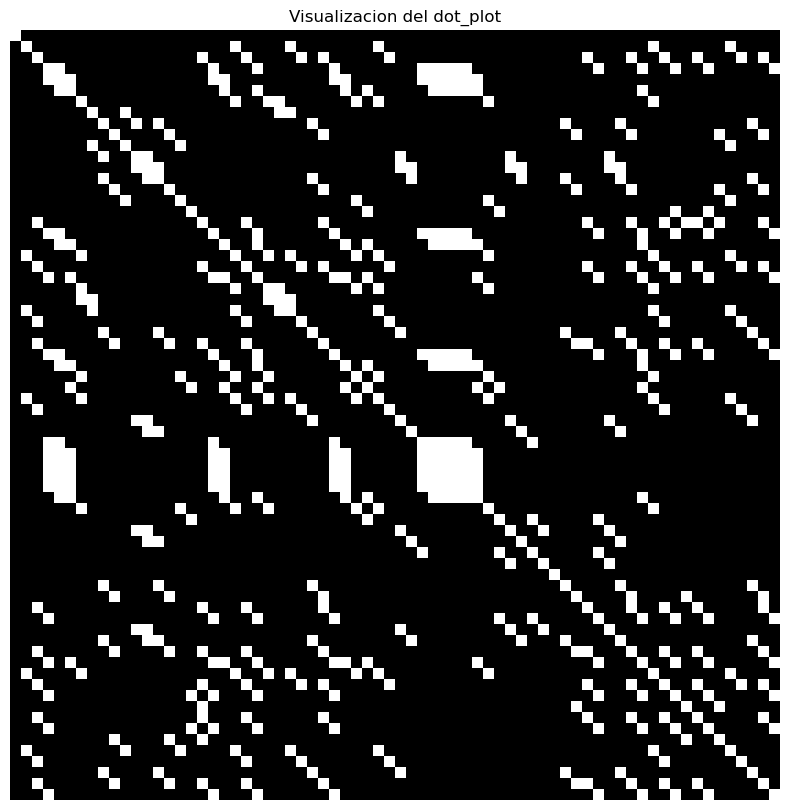

In [9]:
#Usando la libreria
from scipy import ndimage

def filtro_solapado(imagen):
    # Kernel solo vecinos permitidos (quita sup. derecha [0,2] y inf. izq [2,0])
    kernel_validos = np.array([[1,0,0],
                               [0,0,0],
                               [0,0,1]], dtype=np.uint8)

    # Conteo de vecinos
    vecinos_validos = ndimage.convolve(imagen, kernel_validos, mode="constant", cval=0)

    resultado = np.where((imagen == 1) & (vecinos_validos > 0), 1, 0)
    return resultado

imagen_filtrada = filtro_solapado(dotplot)

plt.figure(figsize=(10,10))
plt.imshow(imagen_filtrada, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
plt.title("Visualizacion del dot_plot")
plt.axis("off")
plt.show()

#El objetivo es recorrer toda la matriz e ir revisando si tiene unos cerca, para poder contarlo como valido. si tengo un 1 aislado, lo quito
#def filtro2(image):
#    filas, columas = image.shape()
#    for fila, f in enumerate(filas):
#        for columna, c in enumerate(columnas):
#            vecinos validos (image)
#            if image[f][c] == 1 and 
            
    
    

(-0.5, 69.5, 69.5, -0.5)

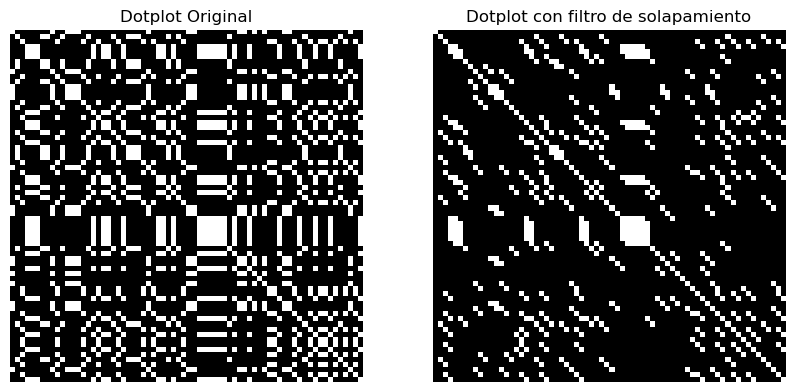

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(10, 10))

axs[0].imshow(dotplot, cmap='gray', clim=(0,1))
axs[0].set_title("Dotplot Original")
axs[0].axis("off")

axs[1].imshow(imagen_filtrada, cmap='gray', clim=(0,1))
axs[1].set_title("Dotplot con filtro de solapamiento")
axs[1].axis("off")


Vemos que el filtro funciona. Hagamos otro para ver si obtenemos distintas imagenes

In [11]:
def filtro_reduccion(imagen):
    filas, columnas = imagen.shape[0],  imagen.shape[1]
    
    # dimensiones reducidas
    cant_filas = filas // 2 if filas % 2 == 0 else (filas - 1) // 2
    cant_columnas = columnas // 2 if columnas % 2 == 0 else (columnas - 1) // 2
    
    objetivo = np.array([[1,0],
                         [0,1]], dtype=np.uint8)
    
    imagen_filtrada = np.zeros((cant_filas, cant_columnas), dtype=np.uint8)
    
    for i in range(0, filas - 1, 2):
        for j in range(0, columnas - 1, 2):
            ventana = imagen[i:i+2, j:j+2]
            imagen_filtrada[i//2, j//2] = 1 if np.array_equal(objetivo, ventana) else 0
            
    return imagen_filtrada


(-0.5, 34.5, 34.5, -0.5)

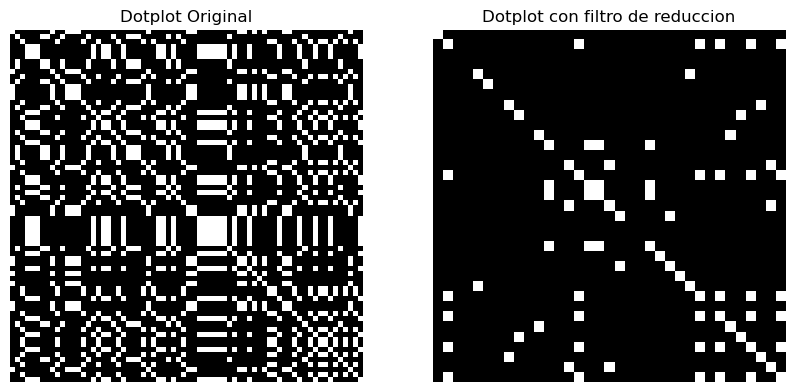

In [12]:
dotplot_filtrado = filtro_reduccion(dotplot)
fig, axs = plt.subplots(1, 2, figsize=(10, 10))

axs[0].imshow(dotplot, cmap='gray', clim=(0,1))
axs[0].set_title("Dotplot Original")
axs[0].axis("off")

axs[1].imshow(dotplot_filtrado, cmap='gray', clim=(0,1))
axs[1].set_title("Dotplot con filtro de reduccion")
axs[1].axis("off")


El siguiente algoritmo consigue un alineamiento global. Por lo que considera que la solucion empieza en la posicion (0,0) y en una matriz de nxn, el camino mas optimo terminara en la celda (n,n)

[[ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  1  1  1]
 [ 0  0  1 ...  2  2  2]
 ...
 [ 0  1  2 ... 39 39 39]
 [ 0  1  2 ... 39 39 39]
 [ 0  1  2 ... 40 40 40]]


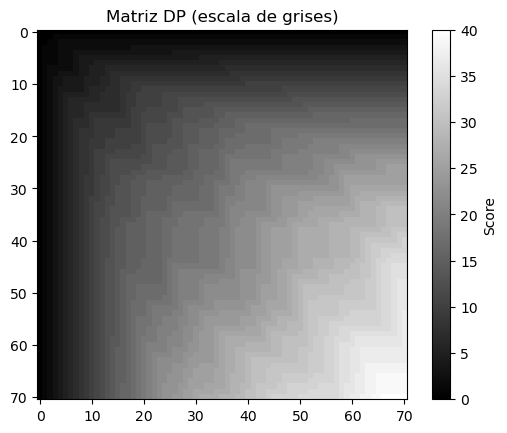

In [19]:
def puntaje_acum(s1, s2):
    n, m = len(s1), len(s2)
    dp = np.zeros((n+1, m+1), dtype=int)
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i,j] = dp[i-1, j-1] + 1
            else:
                dp[i,j] = max(dp[i-1, j],dp[i, j-1], dp[i-1, j-1])
    return dp

print(puntaje_acum(seq1,seq2))
matriz_puntaje_acum = puntaje_acum(seq1,seq2)

plt.imshow(matriz_puntaje_acum, cmap="gray", origin="upper")  
plt.colorbar(label="Score")
plt.title("Matriz DP (escala de grises)")
plt.show()


Con la funcion de arriba podemos ver donde se obtiene el maximo alineamiento (aca que no penalizamos con numeros negativos seguro que va a andar por la esquina inferior derecha, pero si sumamos penalidad por gaps, podriamos tener que el mejor alineamiento no estaria por ahi. Es por eso que cuando reconstruye el camino, le pasamos la celda desde donde tiene que reconstruir. Aca lo hacemos manualmente pidiendolo, pero si quisieramos podriamos pedir que arranque desde el puntaje maximo para automatizarlo)

In [14]:
def camino_dotplot(seq1, seq2):
    n, m = len(seq1), len(seq2)
    # Matriz de dotplot (ponemos columna y filas de ceros al principio para tener los casos bases cubiertos)
    dp = np.zeros((n+1, m+1), dtype=int)
    # registramos las coordenadas
    coords = np.zeros((n+1, m+1), dtype=tuple)

    # en cada celda guardamos de donde viene el mejor puntaje
    # consideremos que pusimos una primer fila y primer columna de ceros. para que pueda hacer el primer caso
    for i in range(1, n+1):
        for j in range(1, m+1):
            # vemos de donde viene el mejor puntaje
            # como dp tiene una columna y filas mas de ceros. la posicion (k,k) en la matriz, es el elemento k-1 en la secuencia
            match = dp[i-1, j-1] + (1 if seq1[i-1] == seq2[j-1] else 0) + 4
            up = dp[i-1, j]
            left = dp[i, j-1]
            dp[i, j] = max(match, up, left)

            # guardamos las coordenadas de donde vino el mejor puntaje en la celda actual
            if dp[i, j] == match:
                coords[i, j] = (i-1, j-1)
            elif dp[i, j] == up:
                coords[i, j] = (i-1, j)
            else:
                coords[i, j] = (i, j-1)
                
    return coords
                
coords = camino_dotplot(seq1,seq2)                
print(coords)

[[0 0 0 ... 0 0 0]
 [0 (0, 0) (0, 1) ... (1, 67) (1, 68) (1, 69)]
 [0 (1, 0) (1, 1) ... (2, 67) (2, 68) (2, 69)]
 ...
 [0 (67, 1) (67, 2) ... (67, 67) (67, 68) (67, 69)]
 [0 (68, 0) (68, 2) ... (68, 67) (68, 68) (68, 69)]
 [0 (69, 1) (69, 2) ... (69, 67) (69, 68) (69, 69)]]


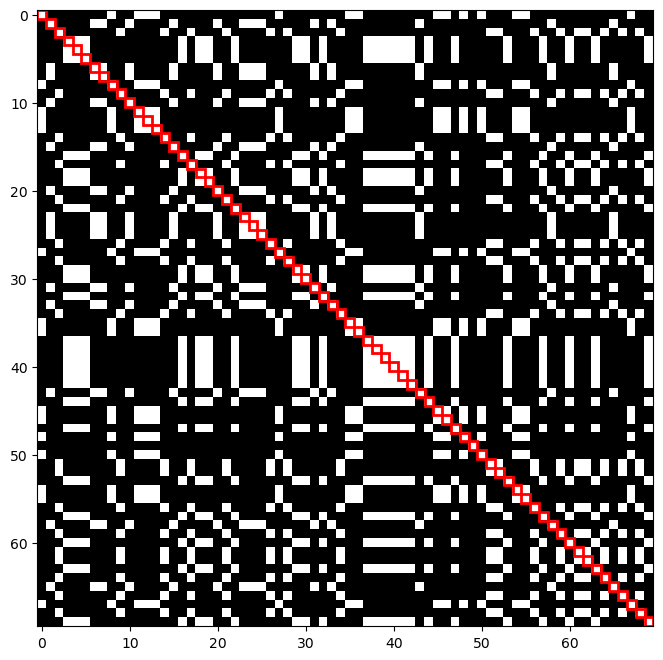

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def dibujar_camino(dotplot, backtrack, start=None, ax=None):
    n, m = dotplot.shape
    
    # Si no me pasan ax, creo uno nuevo
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    # Dibujo el dotplot (0/1)
    ax.imshow(dotplot, cmap=plt.cm.colors.ListedColormap(["black", "white"]), origin="upper")

    # Empiezo desde la esquina inferior derecha si no me pasan start
    if start is None:
        i, j = n-1, m-1
    else:
        i, j = start

    # Trazo el camino hacia atrás
    while True:
        rect = patches.Rectangle((j-0.5, i-0.5), 1, 1, 
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        if not isinstance(backtrack[i, j], tuple):
            break
        i, j = backtrack[i, j]

        if i == 0 and j == 0:
            rect = patches.Rectangle((j-0.5, i-0.5), 1, 1, 
                                     linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            break

    return ax

# Supongamos que ya tenés dotplot y backtrack definidos
ax = dibujar_camino(dotplot, coords)

# Mostrar la figura
plt.show()



Veamos todo junto para poder comparar bien

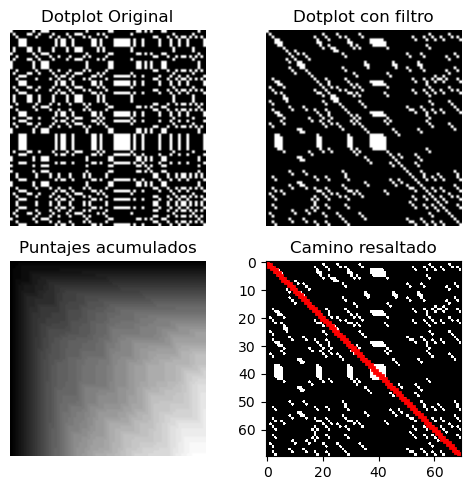

In [16]:
imagen_filtrada = filtro_solapado(dotplot)

fig, axs = plt.subplots(2, 2, figsize=(5, 5))

# Dotplot Original
axs[0,0].imshow(dotplot, cmap='gray', vmin=0, vmax=1)
axs[0,0].set_title("Dotplot Original")
axs[0,0].axis("off")

# Dotplot Filtrado
axs[0,1].imshow(imagen_filtrada, cmap='gray', vmin=0, vmax=1)
axs[0,1].set_title("Dotplot con filtro")
axs[0,1].axis("off")

# Puntajes acumulados
axs[1,0].imshow(matriz_puntaje_acum, cmap='gray')
axs[1,0].set_title("Puntajes acumulados")
axs[1,0].axis("off")

# Camino resaltado en el cuarto subplot
dibujar_camino(imagen_filtrada, coords, ax=axs[1,1])
axs[1,1].set_title("Camino resaltado")

plt.tight_layout()
plt.show()


In [22]:
secuencia1 = "ACGTTCAGTAG"
secuencia2 = "ACCACTTG"

def max_matriz(matriz):
    max_valor = matriz[0][0]
    posicion = (0, 0)
    for i, fila in enumerate(matriz):
        for j, elem in enumerate(fila):
            if elem > max_valor:
                max_valor = elem
                posicion = (i, j)
    return posicion

def seguir_por(seq1, seq2, matriz, fila_inicial, columna_inicial):
    diagonal = matriz[fila_inicial - 1][columna_inicial - 1]
    horizontal = matriz[fila_inicial][columna_inicial - 1]
    vertical = matriz[fila_inicial - 1][columna_inicial]
    maximo = max(diagonal, horizontal, vertical)

    if maximo == diagonal and seq1[fila_inicial - 1] == seq2[columna_inicial - 1]:
        return "d,m"
    elif maximo == diagonal:
        return "d,mm"
    elif maximo == vertical:
        return "vertical"
    else:
        return "horizontal"

def posicion_es_diagonal(fila, columna):
    return fila == columna

def son_iguales(letra1, letra2):
    return letra1 == letra2

def mostrar_alineamiento(seq1, seq2):
    matriz_puntaje = puntaje_acum(seq1, seq2) 
    f, c = max_matriz(matriz_puntaje)

    alineamiento1, alineamiento2, alineamiento3 = [], [], []

    while f > 0 and c > 0:
        siguiente = seguir_por(seq1, seq2, matriz_puntaje, f, c)

        if siguiente == "d,m":
            alineamiento1.append(seq1[f-1])
            alineamiento2.append(seq2[c-1])
            alineamiento3.append("*")
            f, c = f-1, c-1
        elif siguiente == "d,mm":
            alineamiento1.append(seq1[f-1])
            alineamiento2.append(seq2[c-1])
            alineamiento3.append(" ")
            f, c = f-1, c-1
        elif siguiente == "vertical":
            alineamiento1.append(seq1[f-1])
            alineamiento2.append("-")
            alineamiento3.append(" ")
            f = f-1
        elif siguiente == "horizontal":
            alineamiento1.append("-")
            alineamiento2.append(seq2[c-1])
            alineamiento3.append(" ")
            c = c-1

    print("".join(reversed(alineamiento1)))
    print("".join(reversed(alineamiento2)))
    print("".join(reversed(alineamiento3)))

    
mostrar_alineamiento(secuencia1, secuencia2)
mostrar_alineamiento(seq1, seq2)



6
ACGTTCAGTAG
AC---CACTTG
**   ** * *
40
TC-GAA--A-CC-T-G-C---TTTGCA-GAACG-ACCCGT-GAAC-ACG-TT-AAAAAACATTATRTGGAT-T-G-ACGAGGAGCGTGA
TCTTAATCATCCATTGTCGGGT---CATG---GGA----TYGA-CCATGGTTGA----TC-TTAT--G-CTCTCGTAC-A--AAC---A
**  **  * ** * * *   *   ** *   * *    * ** * * * ** *     * ****  *  * * * ** *  * *   *
